In [3]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("water_potability.csv")

In [4]:
df.shape

(3276, 10)

*Data Understanding and EDA*

In [5]:
df.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [7]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [8]:
import seaborn as sns

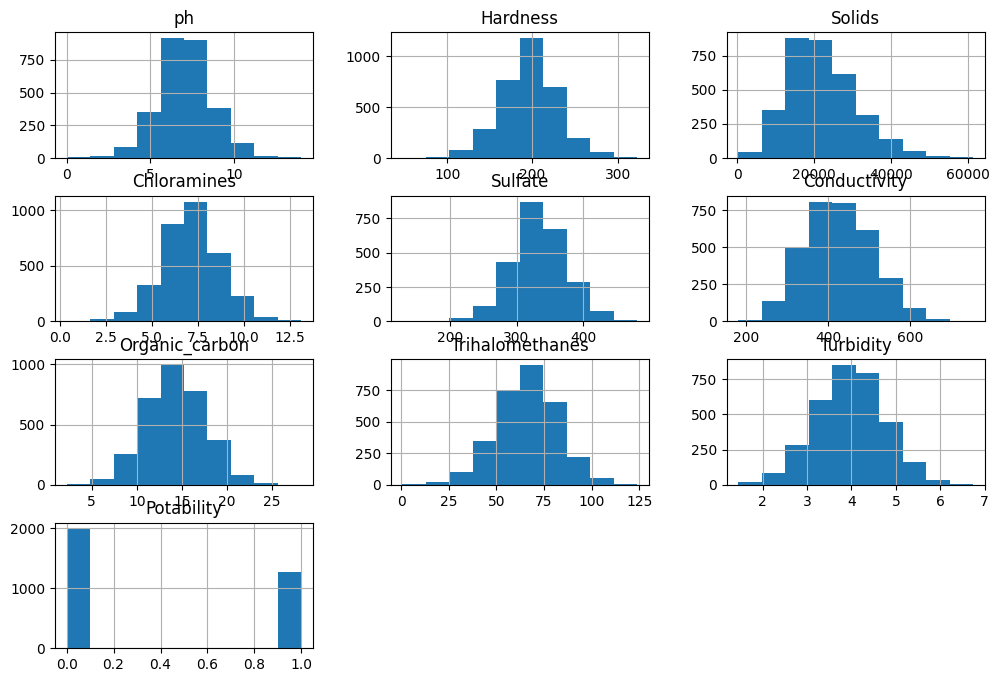

In [9]:
df.hist(figsize=(12, 8))
plt.show()

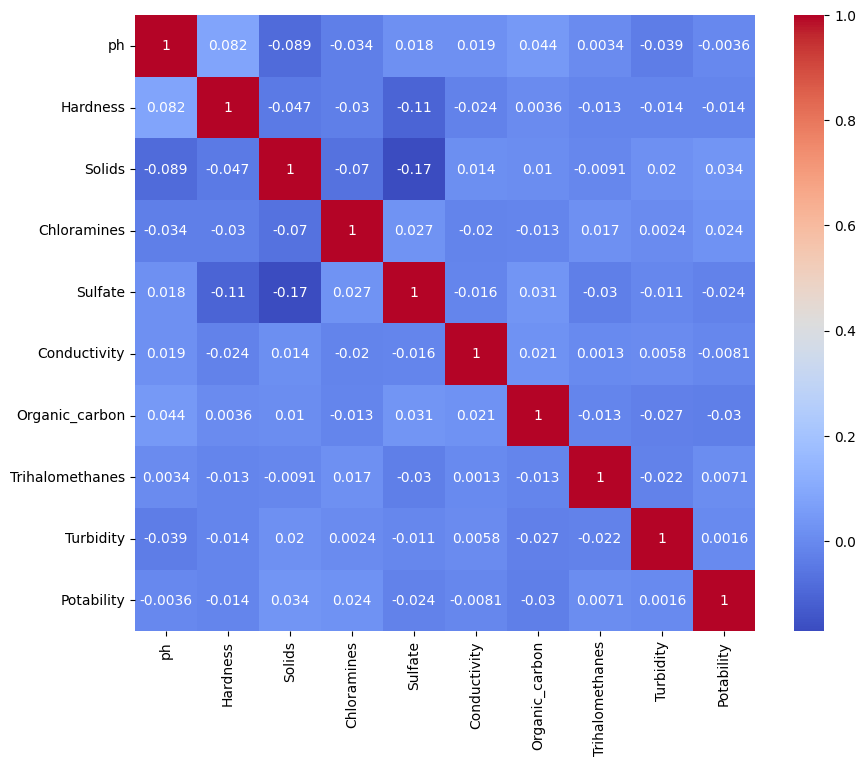

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

Checking missing values based of percentage

In [11]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [12]:
df.isnull().sum()/len(df)*100

ph                 14.987790
Hardness            0.000000
Solids              0.000000
Chloramines         0.000000
Sulfate            23.840049
Conductivity        0.000000
Organic_carbon      0.000000
Trihalomethanes     4.945055
Turbidity           0.000000
Potability          0.000000
dtype: float64

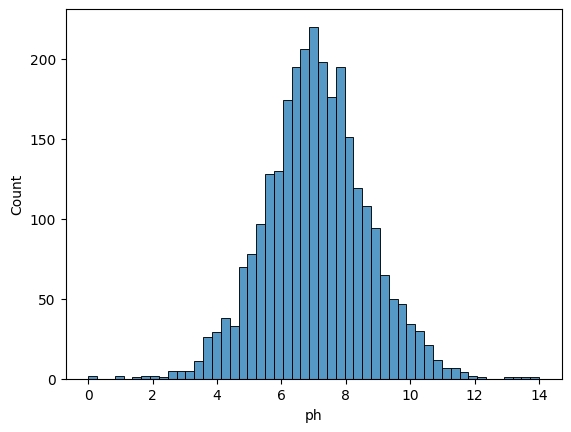

In [13]:

sns.histplot(data=df,x="ph")
plt.show()

Here I can see that ph seems to be perfectly symmetrical so it is wise for me to use the mean to fill in the missing values

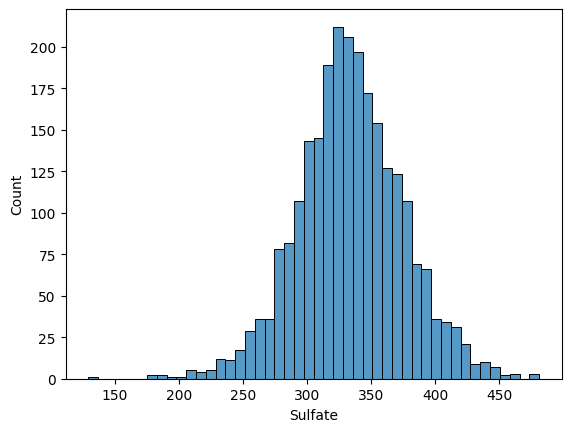

In [14]:
sns.histplot(data=df,x="Sulfate")
plt.show()

In [15]:
df['Sulfate'].skew()

np.float64(-0.03594662160706187)

With sulfate, I will use the median because the data seems to be skewed to the left the most 

In [16]:
df['ph']=df['ph'].fillna(df['ph'].mean())
df['Sulfate']=df['Sulfate'].fillna(df['Sulfate'].mean())

In [17]:
df.dropna(subset=["Trihalomethanes"],inplace=True)
df.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

In [18]:
df.shape

(3114, 10)

In [32]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,3114.000000,3114.000000,3114.000000,3114.000000,3114.000000,3114.000000,3114.000000,3114.000000,3114.000000,3114.000000
mean,7.080246,196.410424,21965.123666,7.123720,333.506735,426.625873,14.280721,66.396293,3.965945,0.392742
std,1.461410,32.886366,8729.800382,1.580280,36.157693,80.955832,3.316893,16.175008,0.777174,0.488439
min,0.000000,73.492234,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.274593,176.797029,15682.104813,6.138326,316.844848,366.327185,12.063955,55.844536,3.442882,0.000000
50%,7.080795,197.089829,20890.593528,7.121371,333.073546,421.990447,14.219418,66.622485,3.956464,0.000000
75%,7.865591,216.721079,27198.150053,8.115199,350.367920,482.435328,16.558601,77.337473,4.497705,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [19]:
Q1 = df['Solids'].quantile(0.25)
Q3 = df['Solids'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Solids'] < Q1 - 1.5*IQR) | (df['Solids'] > Q3 + 1.5*IQR)]
print(len(outliers))

50


In [20]:
from sklearn.model_selection import train_test_split

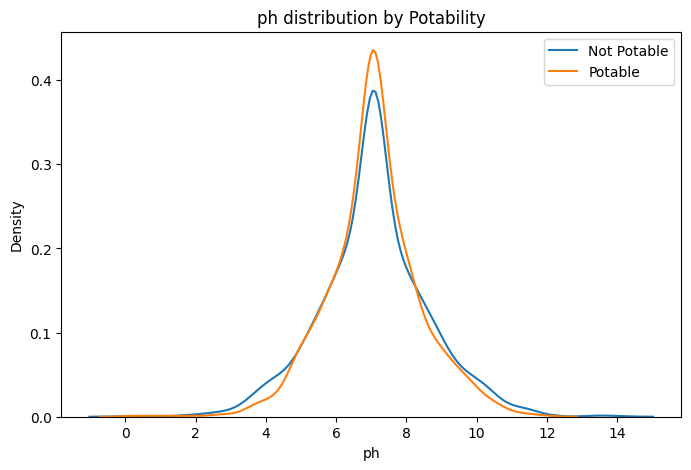

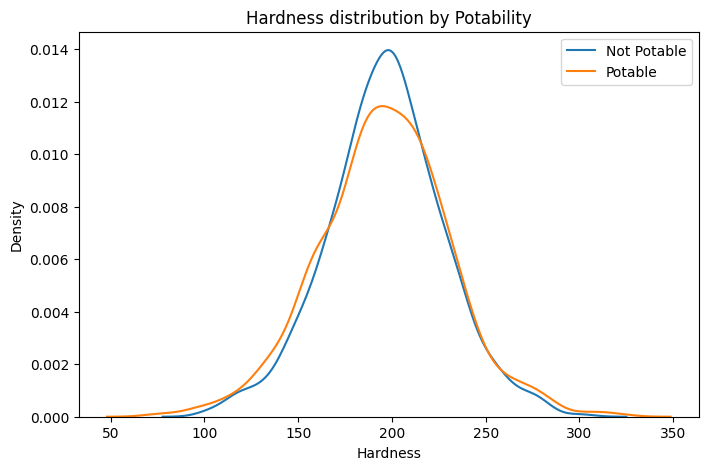

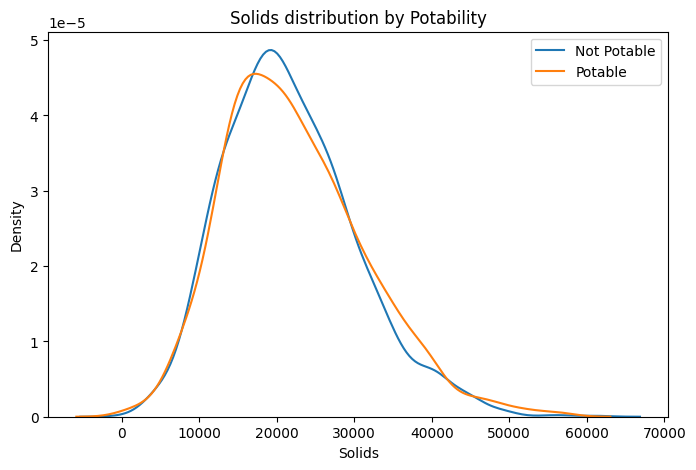

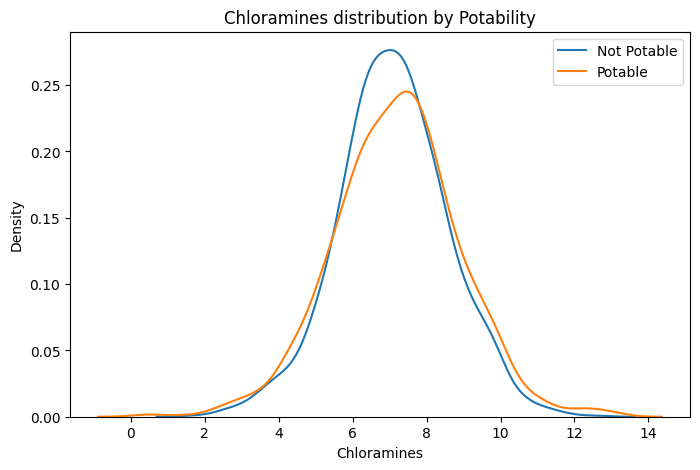

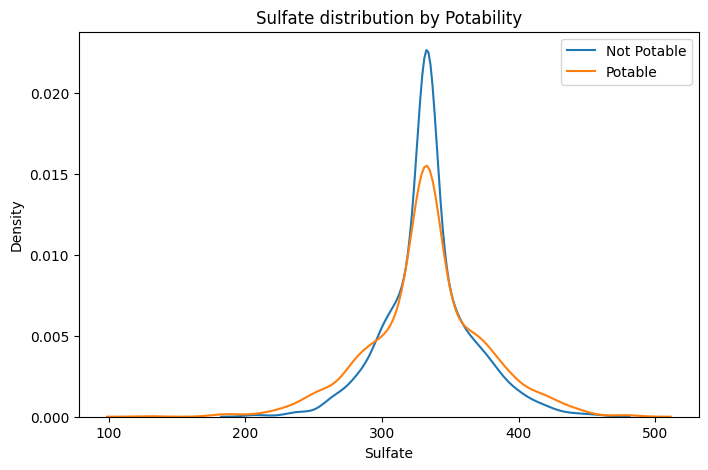

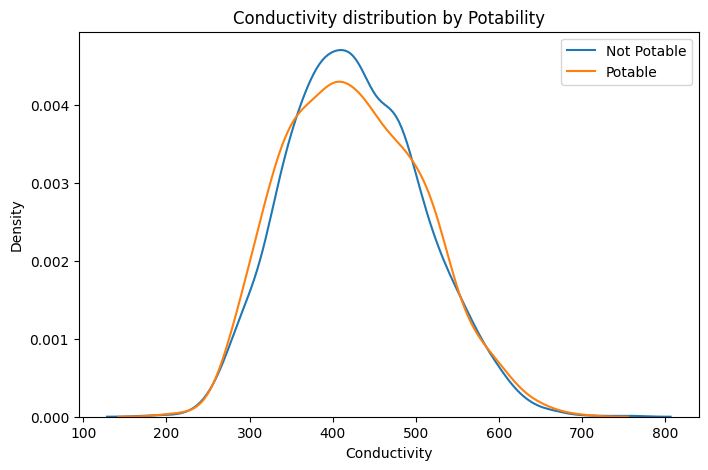

In [59]:
X = df.drop(["Potability",'Organic_carbon', 'Trihalomethanes', 'Turbidity'],axis=1)
y = df["Potability"]

features = X.columns
for feature in features:
    plt.figure(figsize=(8, 5))

    sns.kdeplot(
        data=df[df["Potability"] == 0],
        x=feature,
        label="Not Potable"
    )

    sns.kdeplot(
        data=df[df["Potability"] == 1],
        x=feature,
        label="Potable"
    )

    plt.title(f"{feature} distribution by Potability")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.legend()
    plt.show()

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2,random_state=42,stratify=y)

In [64]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)

print(y_train.value_counts())
print(y_train_smote.value_counts())

Potability
0    1513
1     978
Name: count, dtype: int64
Potability
1    1513
0    1513
Name: count, dtype: int64


In [65]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42, class_weight="balanced_subsample")
model.fit(X_train,y_train)

train_accuracy = model.score(X_train_smote, y_train_smote)


In [66]:
y_pred = model.predict(X_test)

Average of cross validation 67.91162752638901
Training score 91.57303370786516
Prediction score 66.77367576243981
              precision    recall  f1-score   support

           0       0.67      0.88      0.76       378
           1       0.65      0.34      0.45       245

    accuracy                           0.67       623
   macro avg       0.66      0.61      0.60       623
weighted avg       0.66      0.67      0.64       623



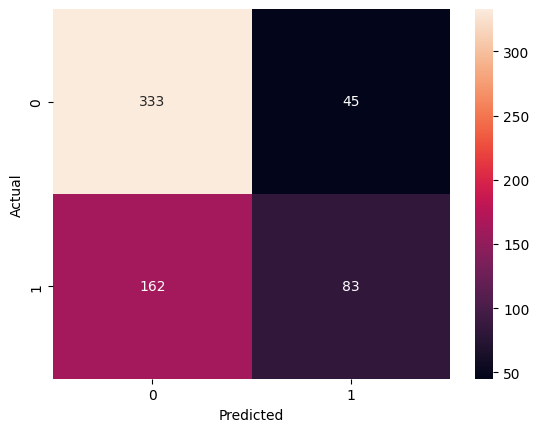

In [68]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model,X_train_smote,y_train_smote,cv=5)
print("Average of cross validation",scores.mean()*100)

print("Training score",train_accuracy*100)
print("Prediction score",accuracy_score(y_test,y_pred)*100)
print(classification_report(y_test,y_pred))
cm= confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Model 2 

In [25]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [26]:
y_xgbpredict = xgb_model.predict(X_test)

In [27]:
print(accuracy_score(y_test,y_xgbpredict))
print(classification_report(y_test,y_xgbpredict))
print(confusion_matrix(y_test,y_xgbpredict))

0.6243980738362761
              precision    recall  f1-score   support

           0       0.69      0.77      0.73       405
           1       0.45      0.36      0.40       218

    accuracy                           0.62       623
   macro avg       0.57      0.56      0.56       623
weighted avg       0.61      0.62      0.61       623

[[311  94]
 [140  78]]


In [28]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.svm import SVC
from sklearn.datasets import load_iris

In [29]:
iris = load_iris()
X,y = iris.data(), iris.target

TypeError: 'numpy.ndarray' object is not callable